<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/Machine_learning/KNN_SocialNetClassData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
path="/content/Social_Net_class.csv"
path

'/content/Social_Net_class.csv'

In [ ]:
data=pd.read_csv(path)
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
data.values[:3]

array([[15624510, 'Male', 19, 19000, 0],
       [15810944, 'Male', 35, 20000, 0],
       [15668575, 'Female', 26, 43000, 0]], dtype=object)

In [ ]:
X = data.iloc[:,:-1]
y = data.iloc[:,4]

In [ ]:
# split the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.20)

In [ ]:
X_train[:3]

,User ID,Gender,Age,EstimatedSalary
234,15619407,Female,38,112000
175,15614420,Female,23,28000
34,15724858,Male,27,90000


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.neighbors import KNeighborsRegressor

In [ ]:
y.unique()

array([0, 1])

In [ ]:
# default value of neighbours: n_neighbors=5

# Drop 'User ID' and apply one-hot encoding to 'Gender' for X_train
X_train_processed = X_train.drop('User ID', axis=1)
X_train_processed = pd.get_dummies(X_train_processed, columns=['Gender'], drop_first=True)

# Drop 'User ID' and apply one-hot encoding to 'Gender' for X_test
X_test_processed = X_test.drop('User ID', axis=1)
X_test_processed = pd.get_dummies(X_test_processed, columns=['Gender'], drop_first=True)

knn = KNeighborsClassifier()
knn.fit(X_train_processed,y_train)
knn.score(X_train_processed,y_train)*100

85.3125

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [ ]:
knn.score(X_test_processed,y_test)*100

80.0

In [ ]:
# Testing phase
y_pred = knn.predict(X_test_processed)
y_pred

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1])

In [ ]:
# check actual and predicted result
display(y_test.values,y_pred)

array([0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1])

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy using y_test and y_pred
accuracy = accuracy_score(y_test, y_pred) * 100
print('Accuracy is:', accuracy)

Accuracy is: 80.0


Data Score- Input + Output

Model score- Actual_output + Predicted_output

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(confusion_matrix(y_test,y_pred))

[[45  7]
 [ 9 19]]


Text(50.72222222222221, 0.5, 'Actual')

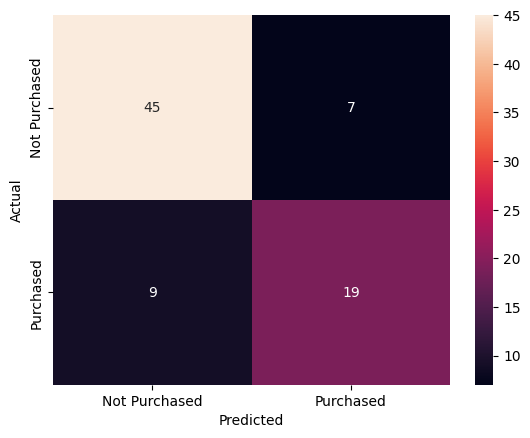

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,
           xticklabels=['Not Purchased','Purchased'],yticklabels=['Not Purchased','Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85        52
           1       0.73      0.68      0.70        28

    accuracy                           0.80        80
   macro avg       0.78      0.77      0.78        80
weighted avg       0.80      0.80      0.80        80



In [ ]:
print(accuracy_score(y_test,y_pred)*100)

80.0


# **Value of K**

In [ ]:
KNeighborsClassifier

sklearn.neighbors._classification.KNeighborsClassifier

In [ ]:
[i for i in range(1,11)]  # k value generation

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [ ]:
for i in range(1,11):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train_processed,y_train) # Use preprocessed data for training
    y_pred = model.predict(X_test_processed) # Use preprocessed data for prediction
    print('for k value:',i,'precision is:',precision_score(y_test,y_pred,average='weighted'))

for k value: 1 precision is: 0.8390466531440162
for k value: 2 precision is: 0.7877911993097498
for k value: 3 precision is: 0.8533333333333335
for k value: 4 precision is: 0.8514106583072101
for k value: 5 precision is: 0.7974358974358975
for k value: 6 precision is: 0.7971786833855798
for k value: 7 precision is: 0.8484330484330485
for k value: 8 precision is: 0.8226190476190476
for k value: 9 precision is: 0.8226190476190476
for k value: 10 precision is: 0.8242946708463951


In [ ]:
from sklearn.metrics import f1_score,confusion_matrix,roc_auc_score
f1_list=[]  # list for f1_score
k_list=[] # list for K value
for k in range(1,11):
    clf=KNeighborsClassifier(n_neighbors=k,n_jobs=-1)
    clf.fit(X_train_processed,y_train) # Use preprocessed data for training
    pred=clf.predict(X_test_processed) # Use preprocessed data for prediction
    f=f1_score(y_test,pred,average='macro')
    f1_list.append(f)
    k_list.append(k)

In [ ]:
for k_val, f1_val in zip(k_list, f1_list):
    print(f'For k value: {k_val}, F1 score is: {f1_val:.4f}')

best_k_f1 = k_list[np.argmax(f1_list)]
max_f1_score = np.max(f1_list)
print(f'\nThe K value with the highest F1 score is: {best_k_f1} with an F1 score of: {max_f1_score:.4f}')

For k value: 1, F1 score is: 0.8229
For k value: 2, F1 score is: 0.7439
For k value: 3, F1 score is: 0.8377
For k value: 4, F1 score is: 0.8255
For k value: 5, F1 score is: 0.7764
For k value: 6, F1 score is: 0.7673
For k value: 7, F1 score is: 0.8323
For k value: 8, F1 score is: 0.8006
For k value: 9, F1 score is: 0.8006
For k value: 10, F1 score is: 0.7964

The K value with the highest F1 score is: 3 with an F1 score of: 0.8377


In [ ]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
# f1_score for clusters 1-10
print(f1_list)

[0.8228581161641968, 0.7439276972321597, 0.8377281947261663, 0.8254545454545454, 0.7763801537386443, 0.7672727272727273, 0.8322851153039832, 0.8005698005698005, 0.8005698005698005, 0.7963636363636364]


In [ ]:
best_f1_score=max(f1_list)
best_k=k_list[f1_list.index(best_f1_score)]
print("Optimum K value=",best_k," with F1-Score=",best_f1_score)

Optimum K value= 3  with F1-Score= 0.8377281947261663


Text(0.5, 1.0, 'K neigbours vs f1_score')

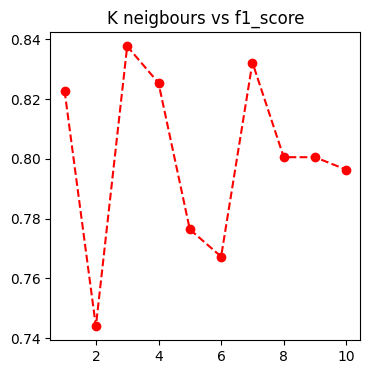

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(k_list,f1_list,'r--o')
plt.title('K neigbours vs f1_score')

Text(0.5, 1.0, 'K neigbours vs f1_score')

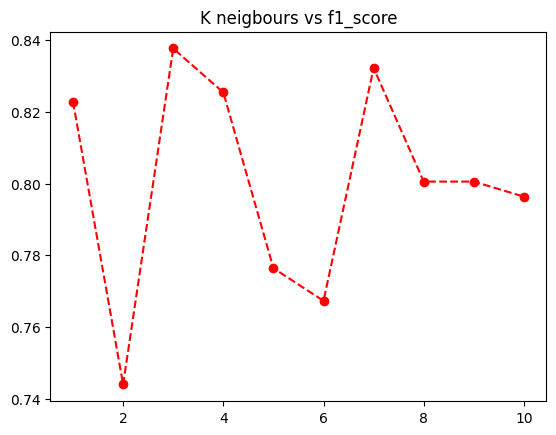

In [ ]:
plt.plot(k_list,f1_list,'r--o')
plt.title('K neigbours vs f1_score')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier(n_neighbors=5)
model_2.fit(X_train_processed,y_train)

KNeighborsClassifier()

In [ ]:
model_2.score(X_train_processed,y_train)*100

85.3125

Find out k using precision

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
p = []
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_processed,y_train)
    pred_i = knn.predict(X_test_processed)
    p.append(precision_score(y_test,pred_i,average='macro'))

In [ ]:
print(p)

[0.8204868154158215, 0.7881794650560828, 0.8333333333333334, 0.85423197492163, 0.782051282051282, 0.7915360501567398, 0.8390313390313391, 0.8154761904761905, 0.8154761904761905, 0.822884012539185, 0.8563636363636363, 0.822884012539185, 0.8035850495804729, 0.822884012539185, 0.834096109839817, 0.811541565778854, 0.8508036338225018, 0.8675213675213675, 0.8675213675213675, 0.822884012539185]


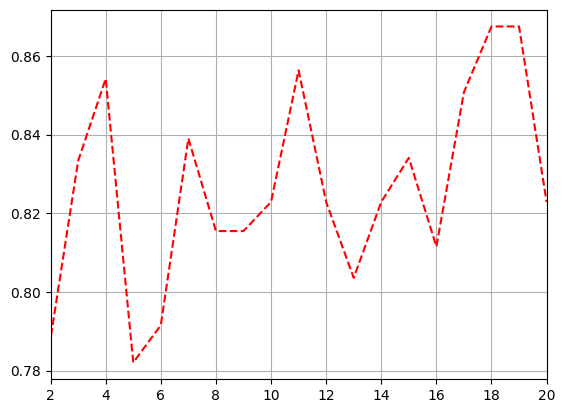

In [ ]:
plt.plot(range(1,21),p,'--r')
plt.xlim((2,20))
plt.grid()

# finding the K value

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.metrics import recall_score

In [ ]:
pr_score = []
for i in range(1,16): #k value [1-15]
    model_1 = KNeighborsClassifier(n_neighbors=i,n_jobs=-1)
    #training
    model_1.fit(X_train_processed,y_train)
    ypred = model_1.predict(X_test_processed)
    p_score = recall_score(y_test,ypred,average='macro')
    print('Recall for k:',i,'is:',round(p_score*100,2))
    pr_score.append(p_score)

Recall for k: 1 is: 82.55
Recall for k: 2 is: 72.94
Recall for k: 3 is: 84.34
Recall for k: 4 is: 81.04
Recall for k: 5 is: 77.2
Recall for k: 6 is: 75.55
Recall for k: 7 is: 82.69
Recall for k: 8 is: 79.12
Recall for k: 9 is: 79.12
Recall for k: 10 is: 78.3
Recall for k: 11 is: 83.65
Recall for k: 12 is: 78.3
Recall for k: 13 is: 77.34
Recall for k: 14 is: 78.3
Recall for k: 15 is: 80.08


In [ ]:
for k_val, recall_val in zip(range(1, 16), pr_score):
    print(f'For k value: {k_val}, Recall score is: {recall_val:.4f}')

best_k_recall = np.argmax(pr_score) + 1 # k values start from 1, so add 1 to index
max_recall_score = np.max(pr_score)
print(f'\nThe K value with the highest Recall score is: {best_k_recall} with a Recall score of: {max_recall_score:.4f}')

For k value: 1, Recall score is: 0.8255
For k value: 2, Recall score is: 0.7294
For k value: 3, Recall score is: 0.8434
For k value: 4, Recall score is: 0.8104
For k value: 5, Recall score is: 0.7720
For k value: 6, Recall score is: 0.7555
For k value: 7, Recall score is: 0.8269
For k value: 8, Recall score is: 0.7912
For k value: 9, Recall score is: 0.7912
For k value: 10, Recall score is: 0.7830
For k value: 11, Recall score is: 0.8365
For k value: 12, Recall score is: 0.7830
For k value: 13, Recall score is: 0.7734
For k value: 14, Recall score is: 0.7830
For k value: 15, Recall score is: 0.8008

The K value with the highest Recall score is: 3 with a Recall score of: 0.8434


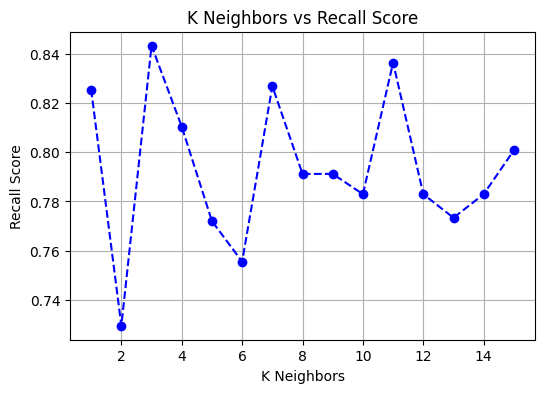

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(range(1,16), pr_score, 'b--o')
plt.title('K Neighbors vs Recall Score')
plt.xlabel('K Neighbors')
plt.ylabel('Recall Score')
plt.grid(True)
plt.show()

In [ ]:
# create pickle file


In [ ]:
import pickle

# Save the trained model to a pickle file
filename = 'knn.pkl'
pickle.dump(model_2, open(filename, 'wb'))

print(f"Model saved successfully to {filename}")

Model saved successfully to knn.pkl
